In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rasterio
import geopandas as gpd
from rasterstats import zonal_stats
import rioxarray
import xvec
from rasterio.transform import Affine
import matplotlib.pyplot as plt
from rasterio.plot import show

Paths to metadata

In [2]:
meta_data = "C:/Users/Chels/OneDrive - University of Illinois - Urbana/Ch6_CASC_Project/Dual-Risk-Repo/Climate_Extremes/climate_threshold_extreme_variables.csv"

Share socioeconomic pathway scenarios

In [3]:
scenarios = np.array(["ssp245","ssp370","ssp585"])
n_s = len(scenarios)

Future year intervals

In [4]:
intervals = np.array(["2041_2070","2071_2100"])
n_y = len(intervals)

Temperature extreme variables

In [5]:
meta_data_df = pd.read_csv(meta_data)
temp_variables = meta_data_df["Temperature"].to_numpy(dtype=str)
temp_variables = temp_variables[temp_variables != 'nan']

Precipitaton extreme variables

In [6]:
precip_variables = meta_data_df["Precipitation"].to_numpy(dtype=str)

Climate threshold and extreme category

In [7]:
threshold_categories = np.array(["pr","temp"])

County zone shapefile

In [8]:
county_shapefile = "F:/Databases/Census/tl_2023_us_county/tl_2023_il_county_clipped_project.shp"
county_polygons = gpd.read_file(county_shapefile)

In [9]:
category = "pr"
scenario = "ssp245"
interval = "2041_2070"
variable = "pr_annual"

In [10]:
# make file path
category_path = f"F:/Wetland_Climate_Impacts/Climate_Data/USGS_Thresholds_Weighted/Grid/{category}/bma_weighted_differences/{scenario}/{interval}"
file_name = f"NCA5_BMA_Weighted_Ensemble_Difference_{variable}_{scenario}_{interval}.nc"
file_path = category_path + "/" + file_name

In [25]:
# open raster
da = xr.open_dataset(file_path, engine="netcdf4", decode_coords="all") #"h5netcdf" "rasterio" 
#da.rio.set_spatial_dims(x_dim="lon", y_dim="lat")
#da.rio.write_crs("EPSG:4326", inplace=True)
da

<xarray.Dataset> Size: 4MB
Dimensions:      (lat: 474, lon: 944)
Coordinates:
  * lat          (lat) float32 2kB 23.91 23.97 24.03 24.09 ... 53.34 53.41 53.47
  * lon          (lon) float32 4kB 234.5 234.6 234.7 234.7 ... 293.3 293.4 293.5
    spatial_ref  int64 8B ...
Data variables:
    pr_annual    (lat, lon) float64 4MB ...

In [21]:
# fix coordinate system

county_polygons.crs = da.rio.crs
raster_da.rio.crs == county_polygons.crs

True

In [14]:
county_polygons['geometry'] = county_polygons['geometry'].buffer(0)
county_polygons = county_polygons[~county_polygons['geometry'].is_empty]
#list(county_polygons.iloc[0].geometry.exterior.coords)

In [15]:
raster_da = raster_da.assign_coords(lon=raster_da.lon - 360)

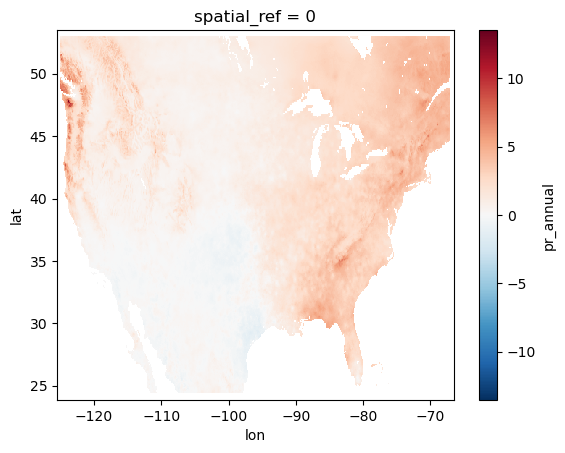

In [16]:
raster_da['pr_annual'].plot()

<Axes: >

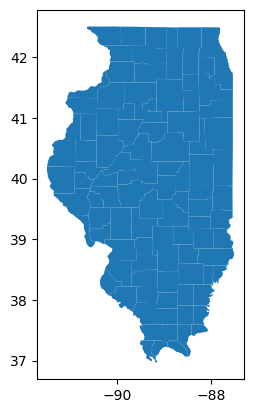

In [17]:
county_polygons.plot()

In [18]:
zone_stats = raster_da.xvec.zonal_stats(county_polygons, 
                                        x_coords="lat",
                                        y_coords="lon",
                                        stats="mean")

C:\Users\Chels\anaconda3\envs\Climate_Ensembles\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape STATEFP at index 0 will not be rasterized.
  warnings.warn(
C:\Users\Chels\anaconda3\envs\Climate_Ensembles\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape COUNTYFP at index 1 will not be rasterized.
  warnings.warn(
C:\Users\Chels\anaconda3\envs\Climate_Ensembles\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape COUNTYNS at index 2 will not be rasterized.
  warnings.warn(
C:\Users\Chels\anaconda3\envs\Climate_Ensembles\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape GEOID at index 3 will not be rasterized.
  warnings.warn(
C:\Users\Chels\anaconda3\envs\Climate_Ensembles\Lib\site-packages\rasterio\features.py:336: ShapeSkipWarning: Invalid or empty shape GEOIDFQ at index 4 will not be rasterized.
  warnings.warn(
C:\Users\Chels\anaconda3\envs\Clima

IndexError: tuple index out of range

In [9]:
# Load raster
#for category in threshold_categories:
#    for scenario in scenarios: 
#        if category == "pr":
#            for variable in precip_variables:
#                for interval in intervals:            